# Unemployment Analysis with Python

## Objective

The objective of this project is to analyze unemployment trends in India using Python. The project aims to explore unemployment data, identify patterns across different states and areas, study the impact of COVID-19 on unemployment rates, and derive meaningful insights through data visualization and exploratory data analysis (EDA).

## Dataset

The dataset contains unemployment statistics for different states and regions of India, including unemployment rate, employment figures, labour participation rate, date, and area (Urban/Rural).

## Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")

In [11]:
df = pd.read_csv("Unemployment in India.csv")

In [12]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [15]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [16]:
df.columns = [
    "Region",
    "Date",
    "Frequency",
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate",
    "Area"
]

In [17]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [18]:
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


In [20]:
print("Regions:")
print(df["Region"].unique())

print("\nAreas:")
print(df["Area"].unique())

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']

Areas:
['Rural' nan 'Urban']


In [21]:
df.isnull().sum()

Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64

In [22]:
df = df.dropna()

In [23]:
df.isnull().sum()

Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

In [24]:
df.shape

(740, 7)

In [25]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


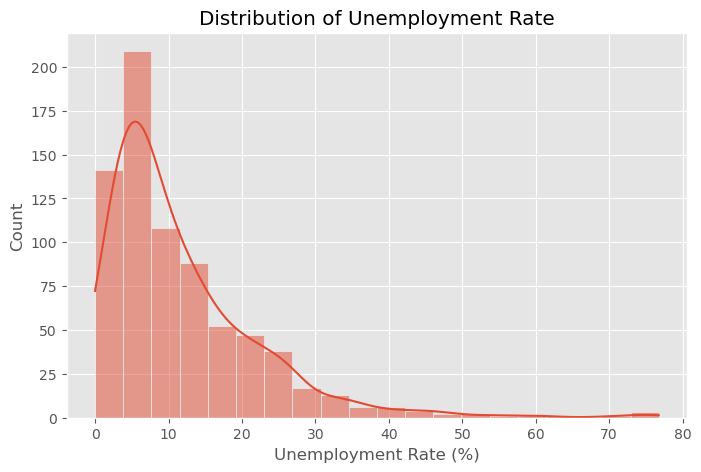

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Unemployment_Rate"], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.savefig("unemployment_distribution.png")
plt.show()

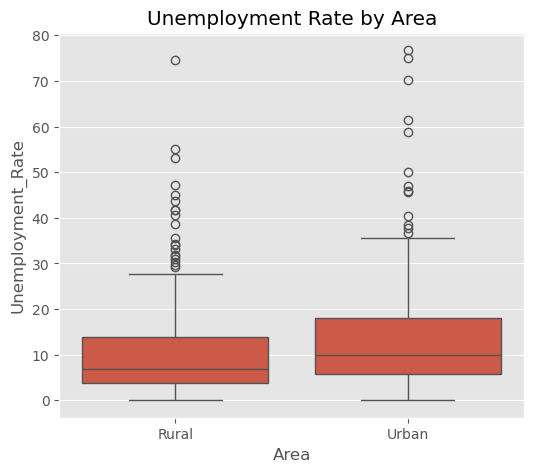

In [29]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Area",
    y="Unemployment_Rate",
    data=df
)
plt.title("Unemployment Rate by Area")
plt.savefig("unemployment_by_area.png")
plt.show()

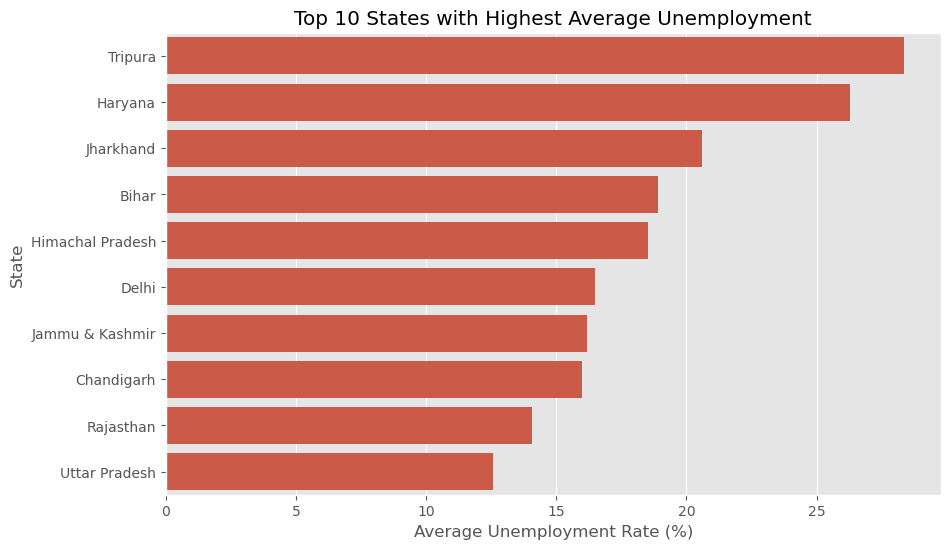

In [31]:
state_unemployment = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)
plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.savefig("top10_states_unemployment.png")
plt.show()

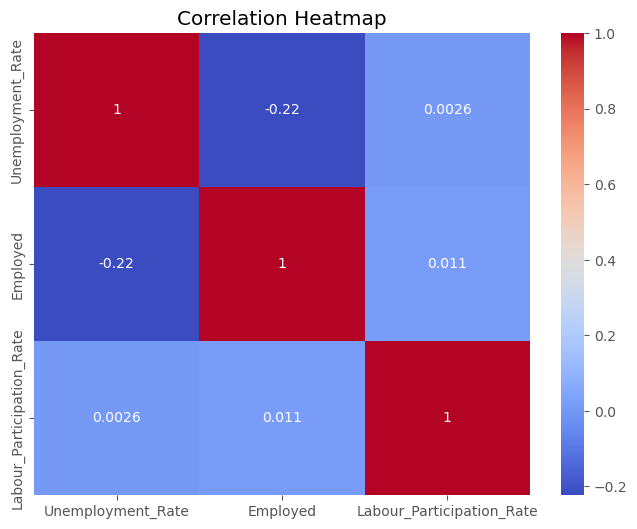

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[[
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.savefig("/correlation_heatmap.png")
plt.show()

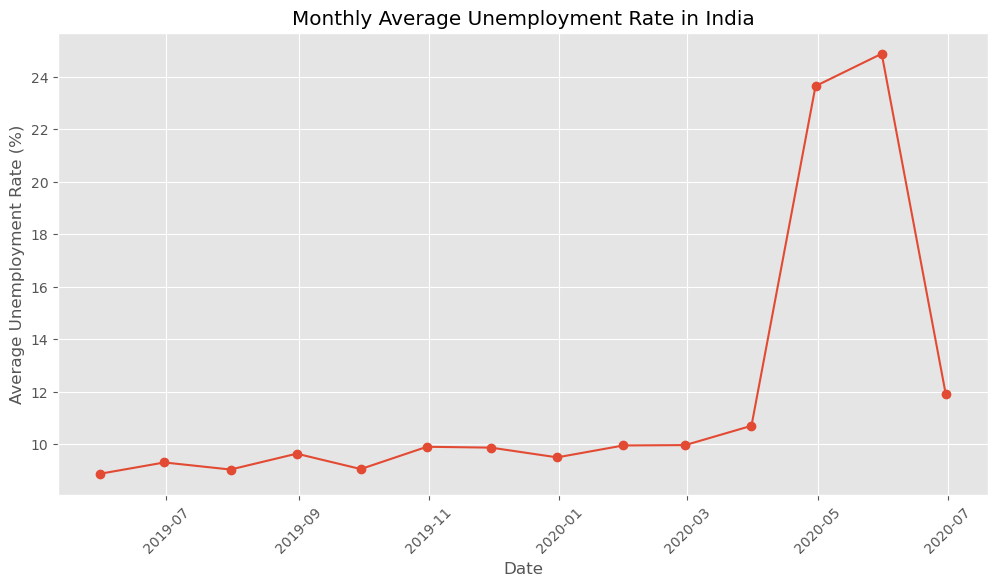

In [33]:
monthly_unemployment = df.groupby("Date")["Unemployment_Rate"].mean()
plt.figure(figsize=(12,6))
plt.plot(monthly_unemployment.index,
         monthly_unemployment.values,
         marker='o')

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.savefig("unemployment_trend.png")
plt.show()

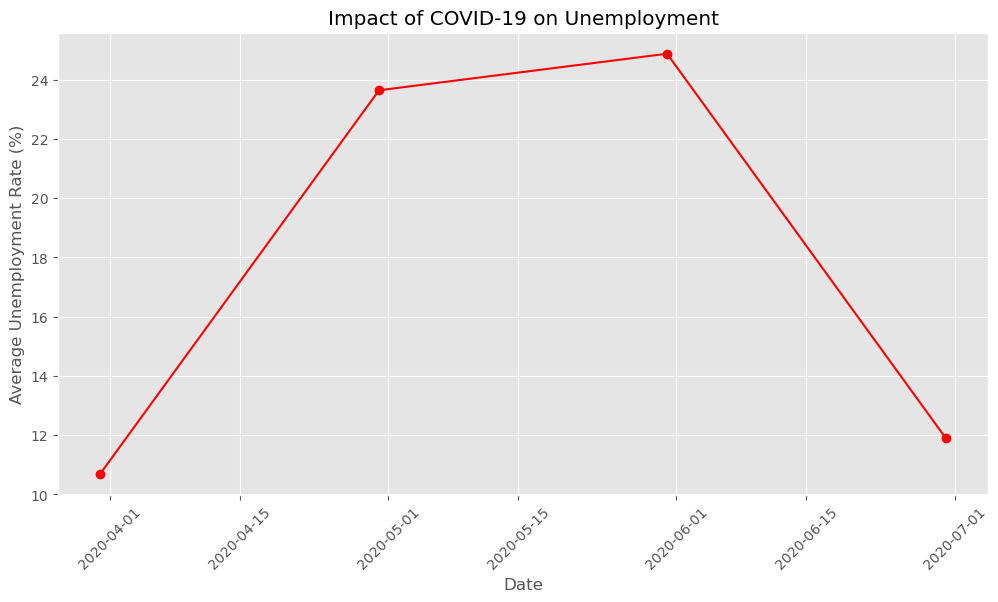

In [34]:
covid_data = df[df["Date"] >= "2020-03-01"]
monthly_covid = covid_data.groupby("Date")["Unemployment_Rate"].mean()
plt.figure(figsize=(12,6))
plt.plot(monthly_covid.index,
         monthly_covid.values,
         marker='o',
         color='red')
plt.title("Impact of COVID-19 on Unemployment")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.savefig("covid_impact.png")
plt.show()

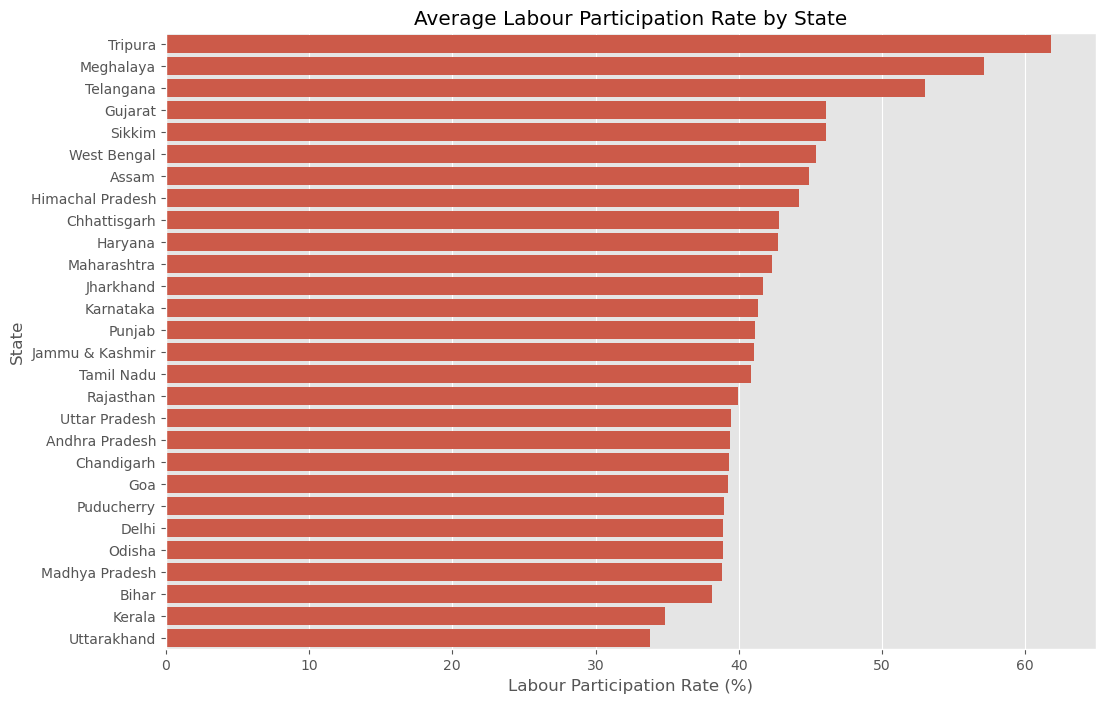

In [35]:
labour = (
    df.groupby("Region")["Labour_Participation_Rate"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,8))
sns.barplot(
    x=labour.values,
    y=labour.index
)
plt.title("Average Labour Participation Rate by State")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("State")
plt.savefig("labour_participation.png")
plt.show()

In [36]:
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [37]:
df2.columns = [
    "Region",
    "Date",
    "Frequency",
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate",
    "Zone",
    "Longitude",
    "Latitude"
]

In [38]:
df2 = df2.dropna()

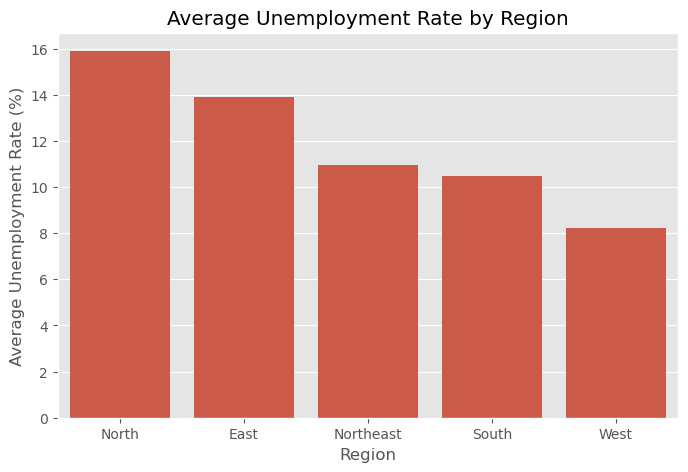

In [39]:
zone = (
    df2.groupby("Zone")["Unemployment_Rate"]
       .mean()
       .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
sns.barplot(
    x=zone.index,
    y=zone.values
)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.savefig("regional_unemployment.png")
plt.show()

## Conclusion

In this project, unemployment data from India was analyzed using Python to understand employment trends across different states and regions. The dataset was cleaned and explored using Exploratory Data Analysis (EDA), and various visualizations were created to identify patterns in unemployment rates, labour participation, and employment levels.

The analysis highlighted the significant impact of COVID-19 on unemployment and revealed noticeable differences across states and between rural and urban areas. Overall, this project demonstrates how data analysis and visualization can be used to gain meaningful insights from real-world datasets and support informed decision-making.